In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
sys.path.append('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/interface/')
os.environ['OMP_NUM_THREADS'] = '8'
import matplotlib
import math
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
from scipy.interpolate import interp1d
import itertools
import iminuit
import functools
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = False
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

# IMPORT CAMB
sys.path.insert(0, '/project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310')
if "camb" in sys.modules:
    del sys.modules["camb"]
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:19:12) [GCC 13.3.0]
/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real


Using CAMB 1.5.9 installed at /project/chihway/junzhou/cocoa_approx/Cocoa/external_modules/code/CAMB/build/lib.linux-x86_64-cpython-310/camb


In [2]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="3x2pt"

path= "./data/"
data_file="roman_ones.dataset"

IA_model = 0
IA_redshift_evolution = 3

ntheta = 20
theta_min_arcmin = 1.0 
theta_max_arcmin = 500.0

As_1e9= 2.1
ns= 0.96605
H0= 67.32
omegab= 0.0495
omegam= 0.316
mnu= 0.06

Roman_DZ_S1= 0.0
Roman_DZ_S2= 0.0
Roman_DZ_S3= 0.0
Roman_DZ_S4= 0.0
Roman_DZ_S5= 0.0
Roman_DZ_S6= 0.0
Roman_DZ_S7= 0.0
Roman_DZ_S8= 0.0


Roman_DZ_L1= 0.0
Roman_DZ_L2= 0.0
Roman_DZ_L3= 0.0
Roman_DZ_L4= 0.0
Roman_DZ_L5= 0.0
Roman_DZ_L6= 0.0
Roman_DZ_L7= 0.0
Roman_DZ_L8= 0.0
Roman_DZ_L9= 0.0
Roman_DZ_L10= 0.0

Roman_M1= 0.0
Roman_M2= 0.0
Roman_M3= 0.0
Roman_M4= 0.0
Roman_M5= 0.0
Roman_M6= 0.0
Roman_M7= 0.0
Roman_M8= 0.0


Roman_A1_1= 0.5
Roman_A1_2= 0.0

Roman_B1_1= 1.09
Roman_B1_2= 1.15
Roman_B1_3= 1.21
Roman_B1_4= 1.27
Roman_B1_5= 1.33
Roman_B1_6= 1.40
Roman_B1_7= 1.46
Roman_B1_8= 1.53
Roman_B1_9= 1.60
Roman_B1_10= 1.67

w0pwa= -1.0
w= -1.0

In [3]:
def get_camb_cosmology(omegam = omegam, 
                       omegab = omegab, 
                       H0 = H0, 
                       ns = ns, 
                       As_1e9 = As_1e9, 
                       w = w, 
                       w0pwa = w0pwa, 
                       AccuracyBoost=1.0, 
                       kmax=5.0, 
                       k_per_logint=10, 
                       CAMBAccuracyBoost=1.0,
                       non_linear_emul=non_linear_emul,
                       lens_potential_accuracy=1.0,
                       halofit_version='takahashi'):

    As = lambda As_1e9: 1e-9 * As_1e9
    wa = lambda w0pwa, w: w0pwa - w
    omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
    omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708
    omegamh2 = lambda omegam, H0: omegam*(H0/100)**2

    CAMBAccuracyBoost = CAMBAccuracyBoost*(1.0 + (AccuracyBoost-1.0)/3.0)
    lens_potential_accuracy = lens_potential_accuracy*CAMBAccuracyBoost
    kmax = kmax*(1.0 + 3*(CAMBAccuracyBoost-1))
    k_per_logint = int(k_per_logint) + int(3*(CAMBAccuracyBoost-1))
    extrap_kmax=2.5e2*CAMBAccuracyBoost
    
    tmp=1250
    z_interp_1D = np.concatenate((np.linspace(0.0,3.0,max(100,int(0.80*tmp))),
                                  np.linspace(3.0,50.1*20,max(100*20,int(0.40*tmp*20)))),axis=0)
    len_z_interp_1D = len(z_interp_1D)
    
    tmp=256
    z_interp_2D = np.concatenate((np.linspace(0,3.0,max(50,int(0.75*tmp))), 
                                  np.linspace(3.01,50.1*20,max(30,int(0.25*tmp)))),axis=0)
    len_z_interp_2D = len(z_interp_2D)
    
    tmp=1500
    log10k_interp_2D = np.linspace(-4.99,2.0,tmp)
    len_log10k_interp_2D = len(log10k_interp_2D)
    
    pars = camb.set_params(H0=H0, 
                           ombh2=omegabh2(omegab, H0), 
                           omch2=omegach2(omegam, omegab, mnu, H0), 
                           mnu=mnu, 
                           omk=0, 
                           tau=0.06,  
                           As=As(As_1e9), 
                           ns=ns, 
                           halofit_version=halofit_version, 
                           lmax=10,
                           AccuracyBoost=CAMBAccuracyBoost,
                           lens_potential_accuracy=lens_potential_accuracy,
                           num_massive_neutrinos=1,
                           nnu=3.046,
                           accurate_massive_neutrino_transfers=False,
                           k_per_logint=k_per_logint,
                           kmax = kmax);
    pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf');    
    pars.NonLinear = model.NonLinear_both
    pars.set_matter_power(redshifts=z_interp_2D, kmax=kmax, silent=True);
    
    results = camb.get_results(pars)
    
    PKL  = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot", 
                                                 nonlinear=False, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units = False, 
                                                 k_hunit = False);
    PKNL = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot",  
                                                 nonlinear=True, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units=False, 
                                                 k_hunit=False);
    
    lnPL = np.log(PKL.P(z_interp_2D,np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
    
    if non_linear_emul == 1:
        params = { 'Omm'  : omegam, 
                   'As'   : As(As_1e9), 
                   'Omb'  : omegab,
                   'ns'   : ns, 
                   'h'    : H0/100., 
                   'mnu'  : mnu,  
                   'w'    : w, 
                   'wa'   : wa(w0pwa, w)
                 }
        kbt, tmp_bt = euclidemu2.get_boost(params,z_interp_2D[z_interp_2D < 10.0],10**np.linspace(-2.0589,0.973,len_log10k_interp_2D))
        bt = np.array(tmp_bt, dtype='float64')  
        tmp = interp1d(np.log10(kbt), 
                        np.log(bt), 
                        axis=1,
                        kind='linear', 
                        fill_value='extrapolate', 
                        assume_sorted=True)(log10k_interp_2D-np.log10(H0/100.)) #h/Mpc
        tmp[:,10**(log10k_interp_2D-np.log10(H0/100)) < 8.73e-3] = 0.0
        lnbt = np.zeros((len_z_interp_2D, len_log10k_interp_2D))
        lnbt[z_interp_2D < 10.0, :] = tmp
        # Use Halofit first that works on all redshifts
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
        # on z < 10.0, replace it with EE2
        lnPNL = np.where((z_interp_2D<10)[:,None], lnPL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F') + lnbt, 
                                                   lnPNL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F')).ravel(order='F')
    elif non_linear_emul == 2:
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3)  
    log10k_interp_2D = log10k_interp_2D - np.log10(H0/100.)
   
    G_growth = np.sqrt(PKL.P(z_interp_2D, 0.0005)/PKL.P(0, 0.0005))*(1 + z_interp_2D)
    G_growth = G_growth/G_growth[len(G_growth)-1]
    
    chi = results.comoving_radial_distance(z_interp_1D) * (H0/100.)
    
    return (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi)

    
def dlnC_ss_dlnK_tomo_limber(ell,
                     ks, 
                     omegam = omegam, 
                     omegab = omegab, 
                     H0 = H0, 
                     ns = ns, 
                     As_1e9 = As_1e9, 
                     w = w, 
                     w0pwa = w0pwa,
                     A1  = [Roman_A1_1, Roman_A1_2, 0, 0, 0, 0, 0, 0], 
                     A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                     BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                     shear_photoz_bias = [Roman_DZ_S1, Roman_DZ_S2, Roman_DZ_S3, Roman_DZ_S4, Roman_DZ_S5, Roman_DZ_S6, Roman_DZ_S7, Roman_DZ_S8],
                     M = [0, 0, 0, 0, 0, 0, 0, 0],
                     baryon_sims = None,
                     AccuracyBoost = 1.0, 
                     kmax = 5.0, 
                     k_per_logint = 10, 
                     CAMBAccuracyBoost=1.0,
                     CLAccuracyBoost = 1.0, 
                     CLIntegrationAccuracy=0,
                     non_linear_emul=non_linear_emul):
    #print('get into camb')
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                               omegab=omegab,
                                                                               H0=H0,
                                                                               ns=ns,
                                                                               As_1e9=As_1e9,
                                                                               w=w,
                                                                               w0pwa=w0pwa,
                                                                               AccuracyBoost=AccuracyBoost,
                                                                               kmax=kmax,
                                                                               k_per_logint=k_per_logint,
                                                                               CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                               non_linear_emul=non_linear_emul)
    #print('camb done!')
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    #print('get into set cosmology')
    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)
    #print('get into main function')      
    return ci.dlnC_ss_dlnK_tomo_limber(l = ell,k = ks)

def C_ss_tomo_limber(ell,
                     ks, 
                     omegam = omegam, 
                     omegab = omegab, 
                     H0 = H0, 
                     ns = ns, 
                     As_1e9 = As_1e9, 
                     w = w, 
                     w0pwa = w0pwa,
                     A1  = [Roman_A1_1, Roman_A1_2, 0, 0, 0, 0, 0, 0], 
                     A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                     BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                     shear_photoz_bias = [Roman_DZ_S1, Roman_DZ_S2, Roman_DZ_S3, Roman_DZ_S4, Roman_DZ_S5, Roman_DZ_S6, Roman_DZ_S7, Roman_DZ_S8],
                     M = [0, 0, 0, 0, 0, 0, 0, 0],
                     baryon_sims = None,
                     AccuracyBoost = 1.0, 
                     kmax = 5.0, 
                     k_per_logint = 10, 
                     CAMBAccuracyBoost=1.0,
                     CLAccuracyBoost = 1.0, 
                     CLIntegrationAccuracy=0,
                     non_linear_emul=non_linear_emul):
    #print('get into camb')
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                               omegab=omegab,
                                                                               H0=H0,
                                                                               ns=ns,
                                                                               As_1e9=As_1e9,
                                                                               w=w,
                                                                               w0pwa=w0pwa,
                                                                               AccuracyBoost=AccuracyBoost,
                                                                               kmax=kmax,
                                                                               k_per_logint=k_per_logint,
                                                                               CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                               non_linear_emul=non_linear_emul)
    #print('camb done!')
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    #print('get into set cosmology')
    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)
    #print('get into main function')      
    return ci.C_ss_tomo_limber(l = ell)

def C_ss_tomo_limber(ell,
                     ks, 
                     omegam = omegam, 
                     omegab = omegab, 
                     H0 = H0, 
                     ns = ns, 
                     As_1e9 = As_1e9, 
                     w = w, 
                     w0pwa = w0pwa,
                     A1  = [Roman_A1_1, Roman_A1_2, 0, 0, 0, 0, 0, 0], 
                     A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                     BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                     shear_photoz_bias = [Roman_DZ_S1, Roman_DZ_S2, Roman_DZ_S3, Roman_DZ_S4, Roman_DZ_S5, Roman_DZ_S6, Roman_DZ_S7, Roman_DZ_S8],
                     M = [0, 0, 0, 0, 0, 0, 0, 0],
                     baryon_sims = None,
                     AccuracyBoost = 1.0, 
                     kmax = 5.0, 
                     k_per_logint = 10, 
                     CAMBAccuracyBoost=1.0,
                     CLAccuracyBoost = 1.0, 
                     CLIntegrationAccuracy=0,
                     non_linear_emul=non_linear_emul):
    #print('get into camb')
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                               omegab=omegab,
                                                                               H0=H0,
                                                                               ns=ns,
                                                                               As_1e9=As_1e9,
                                                                               w=w,
                                                                               w0pwa=w0pwa,
                                                                               AccuracyBoost=AccuracyBoost,
                                                                               kmax=kmax,
                                                                               k_per_logint=k_per_logint,
                                                                               CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                               non_linear_emul=non_linear_emul)
    #print('camb done!')
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    #print('get into set cosmology')
    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    else:
        ci.init_baryons_contamination(sim = baryon_sims)
    #print('get into main function')      
    return ci.C_ss_tomo_limber(l = ell)

In [4]:
adopt_limber_gg = 1
adopt_limber_gs = 1
adopt_RSD_gg = 1
adopt_RSD_gs = 1
NCell_interpolation = 1000
Na_interpolation = 1000

# Init Cosmolike
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")
ci.initial_setup(
      adopt_limber_gg,
    adopt_limber_gs,
    adopt_RSD_gg,
    adopt_RSD_gs,
    NCell_interpolation,
    Na_interpolation,)
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
      lens_multihisto_file=lens_file,
      lens_ntomo=int(lens_ntomo), 
      source_multihisto_file=source_file,
      source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))


import faulthandler
faulthandler.enable()
ells = [30, 100, 300, 1000, 3000, 10000]
EEs = []
for ell in ells:
      ks = 10**np.linspace(-2.5,2.5,1000)
      EE, BB = dlnC_ss_dlnK_tomo_limber(ell = ell, ks = ks)
      EEs.append(EE)

0.9997597880765723
1.0008809211059098
0.9996656876954961
0.9996196880933226
0.9996789409098212
0.9991465346824564


/home/junzhou/ipykernel_1808143/1144947081.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '$\\frac{d\\ln{C_\\ell^{ss}}}{d\\ln{K}}$')

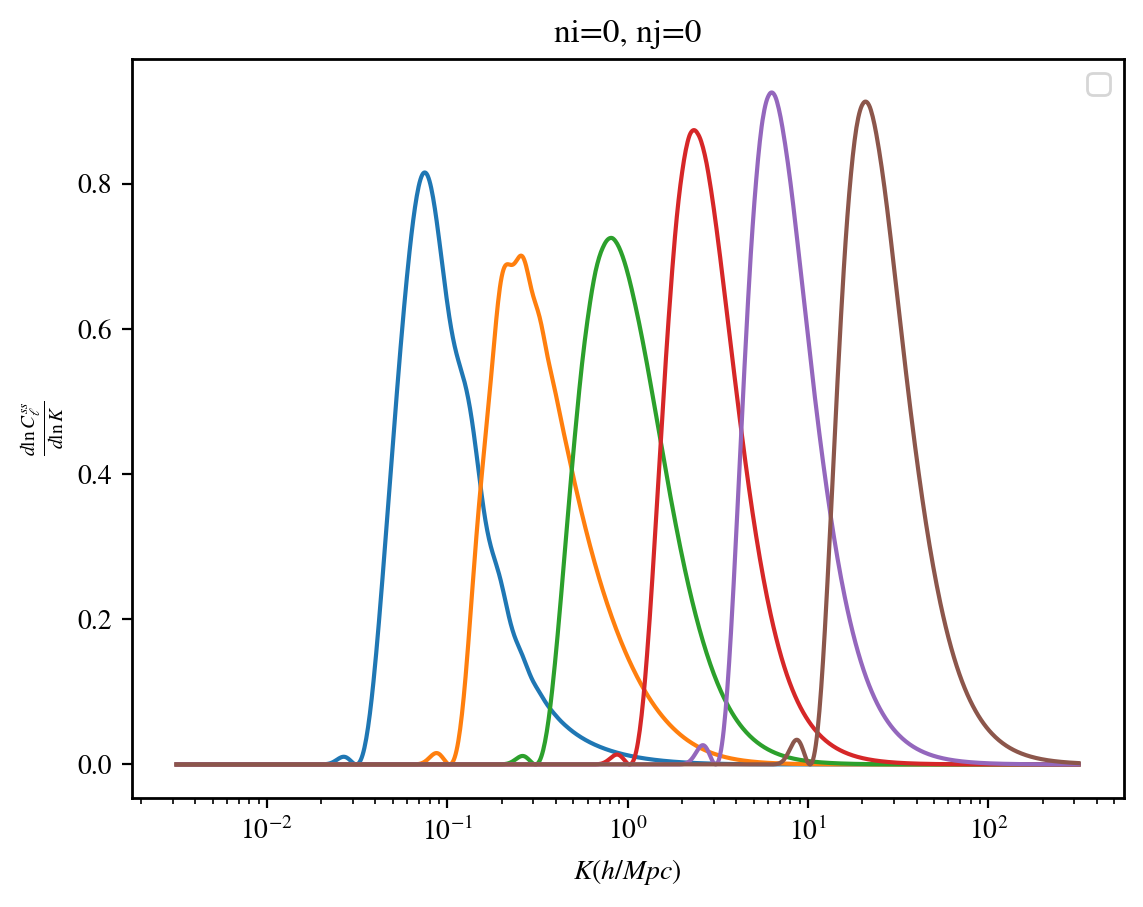

In [5]:
from scipy.interpolate import interp1d
from scipy.integrate import quad

ni = 0
nj = 0
alpha = 0.99
tol = 1e-4
coverH0 = 3e5/100
for i in range(len(ells)):
    ks = 10**np.linspace(-2.5,2.5,1000)
    plt.plot(ks, EEs[i][:,ni,nj])
    Norm = np.trapz(EEs[i][:,ni,nj], np.log(ks))
    print(Norm)

plt.xscale('log')
plt.title(f'ni={ni}, nj={nj}')
plt.legend()
plt.xlabel(r'$ K (h/Mpc)$')
plt.ylabel(r'$\frac{d\ln{C_\ell^{ss}}}{d\ln{K}}$')

In [ ]:
import glob
import numpy as np
from scipy import special
import time
t0 = time.time()
def log(info):
    print(f'[{time.time()-t0:7.1f}s] {info}')

LMAX = 50000
ni = 0
nj = 0


files_dlnCl = glob.glob('./dlnCldlnK*')
files_dlnCl = np.sort(files_dlnCl)
files_Cl = glob.glob('./C_ss_over*')
files_Cl = np.sort(files_Cl)
dlnCldlnK = []
Cl = []
for file in files_dlnCl:
    dlnCldlnK.append(np.load(file)[:,:,ni,nj].astype(np.float32))
for file in files_Cl:
    Cl.append(np.load(file)[:,ni,nj].astype(np.float32))
dlnCldlnK = np.array(dlnCldlnK).reshape(-1,1000)
Cl = np.array(Cl).reshape(-1)
log(f'load clnCkdlnK for ni = {ni}, nj = {nj} succesfuly')
xips, xims = [],[]


thetas = [1, 3, 10, 36, 108, 360]
for theta in thetas:
    theta_rad = theta/60*np.pi/180
    x = np.cos(theta_rad)

    j0, j4 = [],[]
    for l in range(LMAX):
        j0.append(special.jv(0, theta_rad*l))
        j4.append(special.jv(4, theta_rad*l))
    log(f'calculate j0/4 successfully')

    int1 = []
    int2 = []
    for l in range(2, LMAX):
        int1.append(l/2/np.pi*j0[l]*dlnCldlnK[l]*Cl[l])
        int2.append(l/2/np.pi*j4[l]*dlnCldlnK[l]*Cl[l])
    log(f'calculate intergand succesfully')
    
    ls = np.arange(2, LMAX)
    xip = np.trapz(int1, ls, axis=0)
    xim = np.trapz(int2, ls, axis=0)
    
    xips.append(xip)
    xims.append(xim)


[   14.0s] load clnCkdlnK for ni = 0, nj = 0 succesfuly
[   14.2s] calculate j0/4 successfully
[   14.8s] calculate intergand succesfully
[   15.8s] calculate j0/4 successfully
[   16.2s] calculate intergand succesfully
[   17.2s] calculate j0/4 successfully
[   17.6s] calculate intergand succesfully
[   18.6s] calculate j0/4 successfully
[   19.0s] calculate intergand succesfully
[   19.9s] calculate j0/4 successfully
[   20.4s] calculate intergand succesfully
[   21.3s] calculate j0/4 successfully
[   21.7s] calculate intergand succesfully


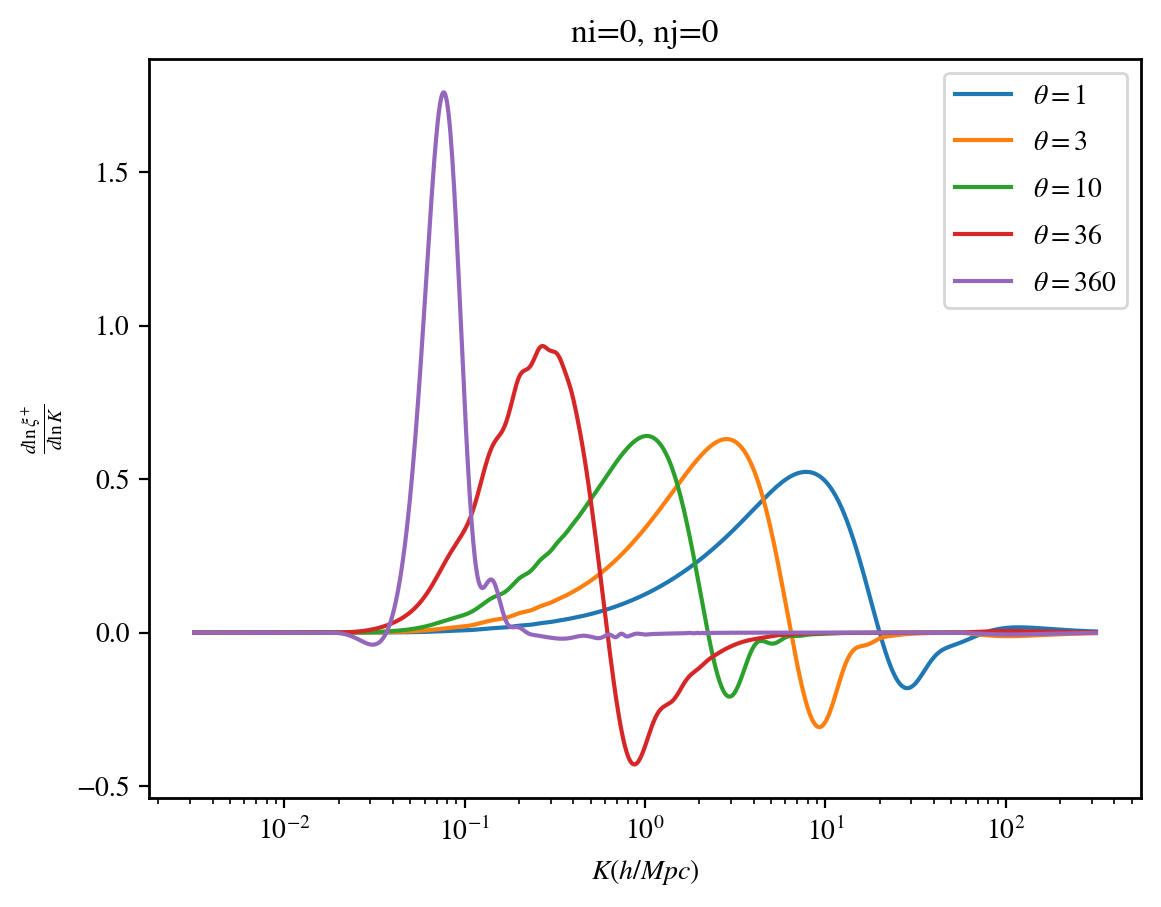

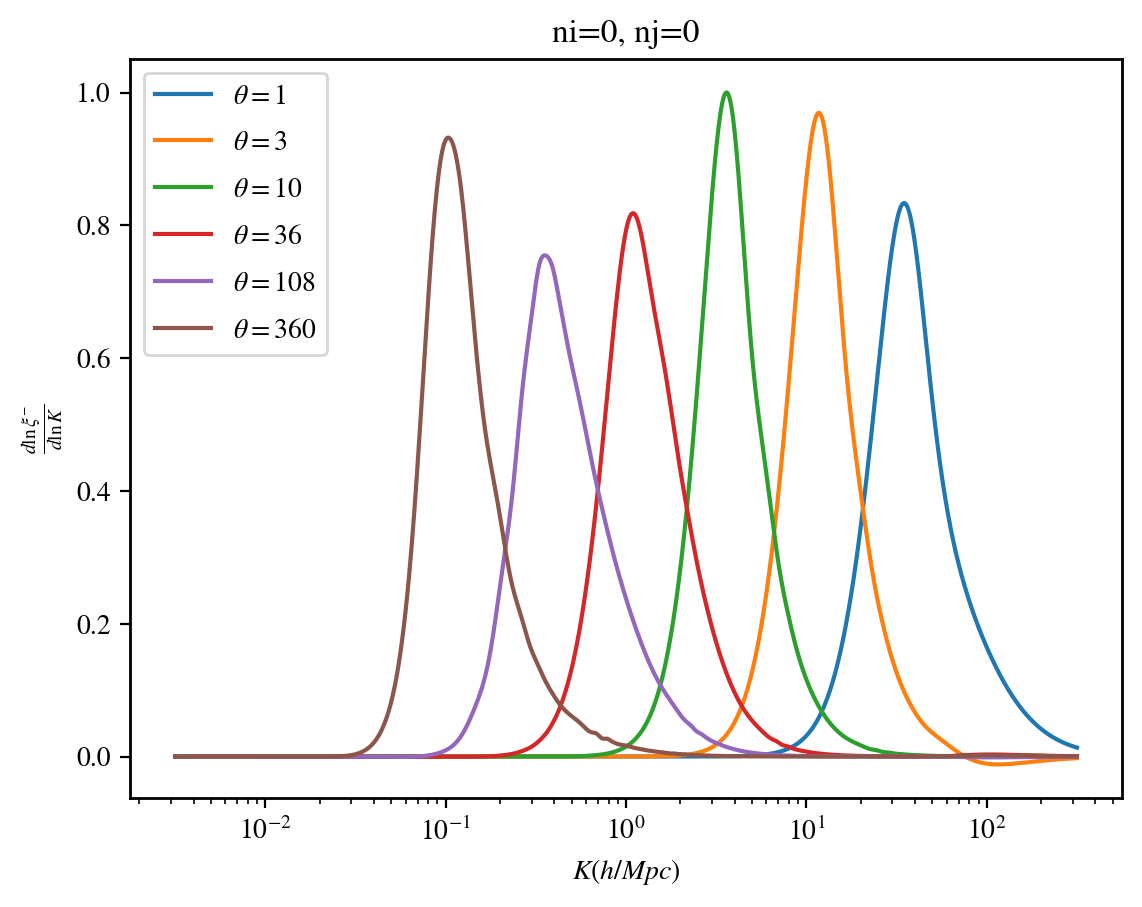

In [15]:


ks = 10**np.linspace(-2.5,2.5,1000)
lnks = np.log(ks)

import matplotlib.pyplot as plt

for i,theta in enumerate(thetas):
    if theta==108:
        continue
    Norm = np.trapz(xips[i], lnks)
    plt.plot(ks, xips[i]/Norm, label=rf'$\theta={theta}$')
plt.title(f'ni={ni}, nj={nj}')
plt.xlabel(r'$ K (h/Mpc)$')
plt.ylabel(r'$\frac{d\ln{\xi^{+}}}{d\ln{K}}$')
plt.xscale('log')
plt.legend()
plt.show()
for i,theta in enumerate(thetas):
    Norm = np.trapz(xims[i], lnks)
    plt.plot(ks, xims[i]/Norm, label=rf'$\theta={theta}$')
plt.title(f'ni={ni}, nj={nj}')
plt.xlabel(r'$ K (h/Mpc)$')
plt.ylabel(r'$\frac{d\ln{\xi^{-}}}{d\ln{K}}$')
plt.xscale('log')
plt.legend()
plt.show()

In [13]:
import glob
import numpy as np
from scipy import special
import time
t0 = time.time()
def log(info):
    print(f'[{time.time()-t0:7.1f}s] {info}')

LMAX = 50000
ni = 0
nj = 0


files_dlnCl = glob.glob('./dlnCldlnK*')
files_dlnCl = np.sort(files_dlnCl)
files_Cl = glob.glob('./C_ss_over*')
files_Cl = np.sort(files_Cl)
dlnCldlnK = []
Cl = []
for file in files_dlnCl:
    dlnCldlnK.append(np.load(file)[:,:,ni,nj].astype(np.float32))
for file in files_Cl:
    Cl.append(np.load(file)[:,ni,nj].astype(np.float32))
dlnCldlnK = np.array(dlnCldlnK).reshape(-1,1000)
Cl = np.array(Cl).reshape(-1)
log(f'load clnCkdlnK for ni = {ni}, nj = {nj} succesfuly')
xips, xims = [],[]


thetas = [1, 3, 10, 36, 108, 360]
for theta in thetas:
    theta_rad = theta/60*np.pi/180
    x = np.cos(theta_rad)

    Gl2p, Gl2m = [0,0],[0,0]
    m = 2
    Pl2 = [0,0]
    for l in range(m, LMAX):
        Pl2.append(special.lpmv(m, l, x))
    for l in range(m, LMAX):
        eq1 = -((l-m**2)/(1-x**2) + 0.5*l*(l+1))*Pl2[l] \
                + (l+m)*x/(1-x**2)*Pl2[l-1]
        eq2 = m*((l-1)*x/(1-x**2)*Pl2[l] \
                - (l+m)/(1-x**2)*Pl2[l-1])
        Gl2p.append(eq1)
        Gl2m.append(eq2)
    log(f'calculate Glm^pm successfully')

    int1 = []
    int2 = []
    for l in range(m, LMAX):
        int1.append((2*l+1)/(2*np.pi*l*l*(l+1)*(l+1))*(Gl2p[l] + Gl2m[l])*dlnCldlnK[l]*Cl[l])
        int2.append((2*l+1)/(2*np.pi*l*l*(l+1)*(l+1))*(Gl2p[l] - Gl2m[l])*dlnCldlnK[l]*Cl[l])
    log(f'calculate summation succesfully')
    
    ls = np.arange(2, LMAX)
    xip = np.trapz(int1, ls, axis=0)
    xim = np.trapz(int2, ls, axis=0)
    
    xips.append(xip)
    xims.append(xim)


[    8.7s] load clnCkdlnK for ni = 0, nj = 0 succesfuly
[   16.9s] calculate Glm^pm successfully
[   17.5s] calculate summation succesfully
[   26.4s] calculate Glm^pm successfully
[   27.0s] calculate summation succesfully
[   35.7s] calculate Glm^pm successfully
[   36.2s] calculate summation succesfully
[   44.8s] calculate Glm^pm successfully
[   45.3s] calculate summation succesfully
[   54.2s] calculate Glm^pm successfully
[   54.8s] calculate summation succesfully
[   63.5s] calculate Glm^pm successfully
[   63.9s] calculate summation succesfully


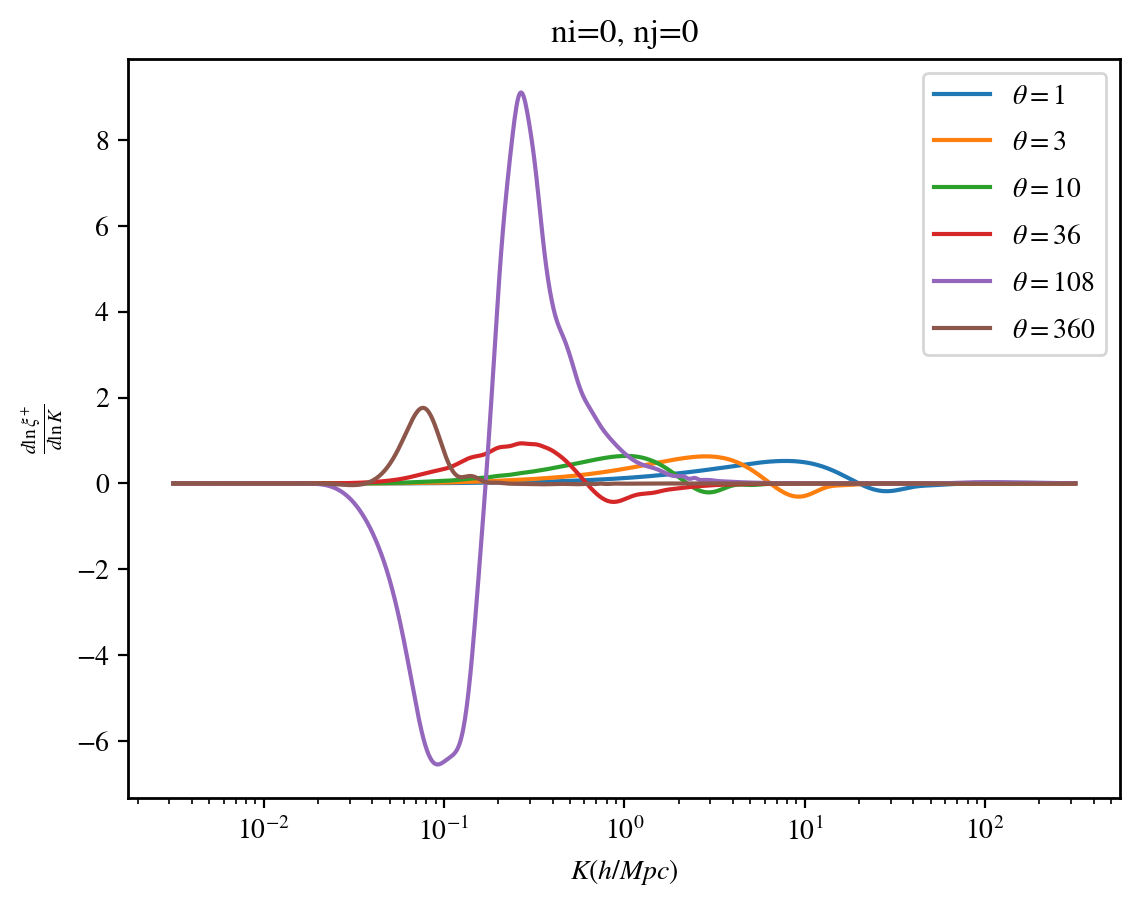

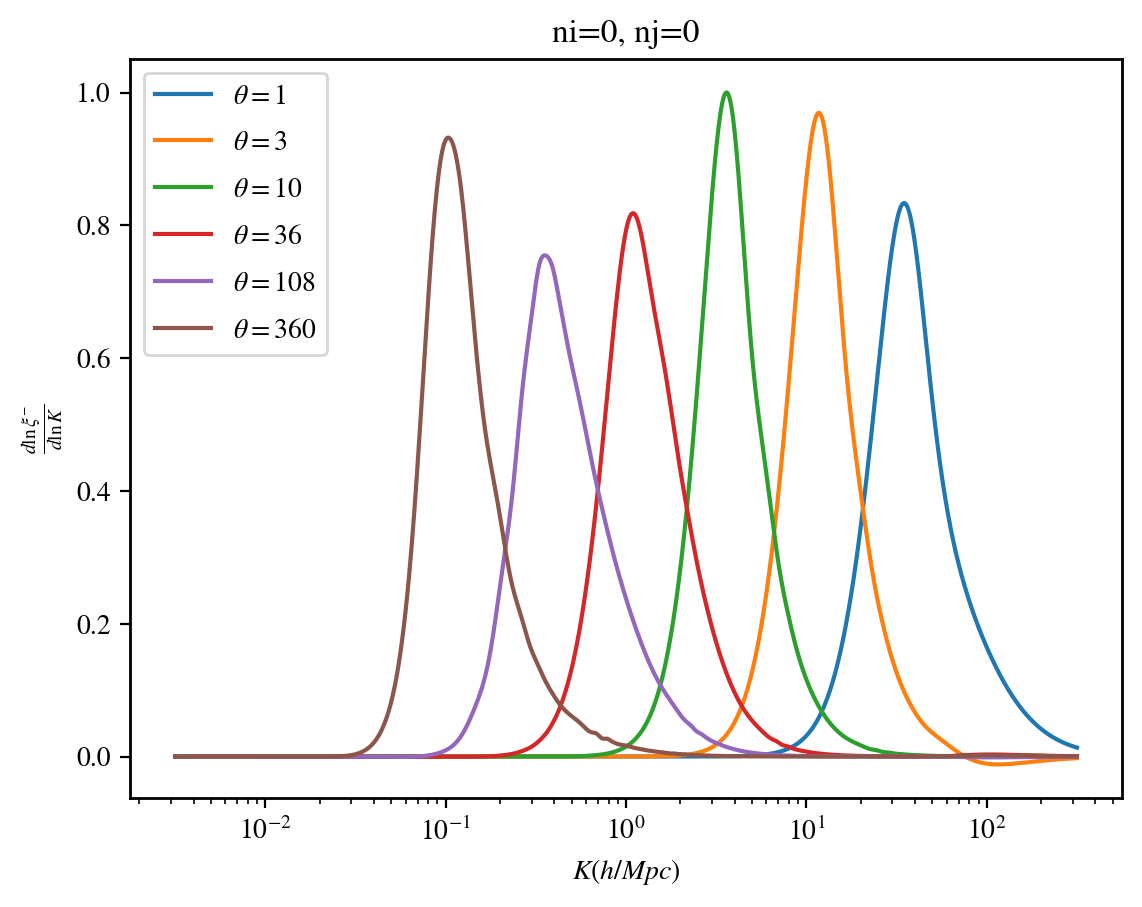

In [14]:
ks = 10**np.linspace(-2.5,2.5,1000)
lnks = np.log(ks)

import matplotlib.pyplot as plt

for i,theta in enumerate(thetas):
    Norm = np.trapz(xips[i], lnks)
    plt.plot(ks, xips[i]/Norm, label=rf'$\theta={theta}$')
plt.title(f'ni={ni}, nj={nj}')
plt.xlabel(r'$ K (h/Mpc)$')
plt.ylabel(r'$\frac{d\ln{\xi^{+}}}{d\ln{K}}$')
plt.xscale('log')
plt.legend()
plt.show()
for i,theta in enumerate(thetas):
    Norm = np.trapz(xims[i], lnks)
    plt.plot(ks, xims[i]/Norm, label=rf'$\theta={theta}$')
plt.title(f'ni={ni}, nj={nj}')
plt.xlabel(r'$ K (h/Mpc)$')
plt.ylabel(r'$\frac{d\ln{\xi^{-}}}{d\ln{K}}$')
plt.xscale('log')
plt.legend()
plt.show()